# Task 2 (cont.) - LSTM Forecasting for TSLA

Deep-learning counterpart to the ARIMA baseline in `2.0-arima-forecasting.ipynb`, on the
same chronological train/test split, so the two can be compared head-to-head on
MAE/RMSE/MAPE.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

sys.path.append(str(Path.cwd().parent))
from src.modeling import make_windows

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)


## 1. Load data and split chronologically

Identical split to the ARIMA notebook: train on 2015-01-02 to 2024-12-31, test on
2025-01-01 to 2026-06-29. The scaler is fit on the training data only, to avoid any
leakage of test-set statistics into the model.

In [2]:
combined = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
tsla = combined[combined["Asset"] == "TSLA"].set_index("Date").sort_index()["Adj Close"]

full_bdays = pd.date_range(tsla.index.min(), tsla.index.max(), freq="B")
tsla = tsla.reindex(full_bdays).ffill()
tsla.index.name = "Date"

TRAIN_END = "2024-12-31"
TEST_START = "2025-01-01"
WINDOW = 60

train = tsla.loc[:TRAIN_END]
test = tsla.loc[TEST_START:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} obs)")

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()

test_context = pd.concat([train.iloc[-WINDOW:], test])
test_context_scaled = scaler.transform(test_context.values.reshape(-1, 1)).flatten()


Train: 2015-01-02 -> 2024-12-31 (2608 obs)
Test:  2025-01-01 -> 2026-06-29 (389 obs)


## 2. Build sequences (60-day lookback window)

Each training example uses the last 60 trading days of scaled price to predict the next
day's scaled price.

In [3]:
X_train, y_train = make_windows(train_scaled, WINDOW)
X_test, y_test = make_windows(test_context_scaled, WINDOW)

X_train = X_train.reshape(-1, WINDOW, 1)
X_test = X_test.reshape(-1, WINDOW, 1)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)
assert len(X_test) == len(test)


X_train: (2548, 60, 1)  y_train: (2548,)
X_test:  (389, 60, 1)  y_test:  (389,)


## 3. LSTM architecture

Two stacked LSTM layers (50 units each) with dropout for regularization, followed by a
dense output layer producing a single scaled price. EarlyStopping on validation loss
guards against overfitting given the relatively small training set.

In [4]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1),
])
model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()


C:\Users\maedo\Time-series-\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

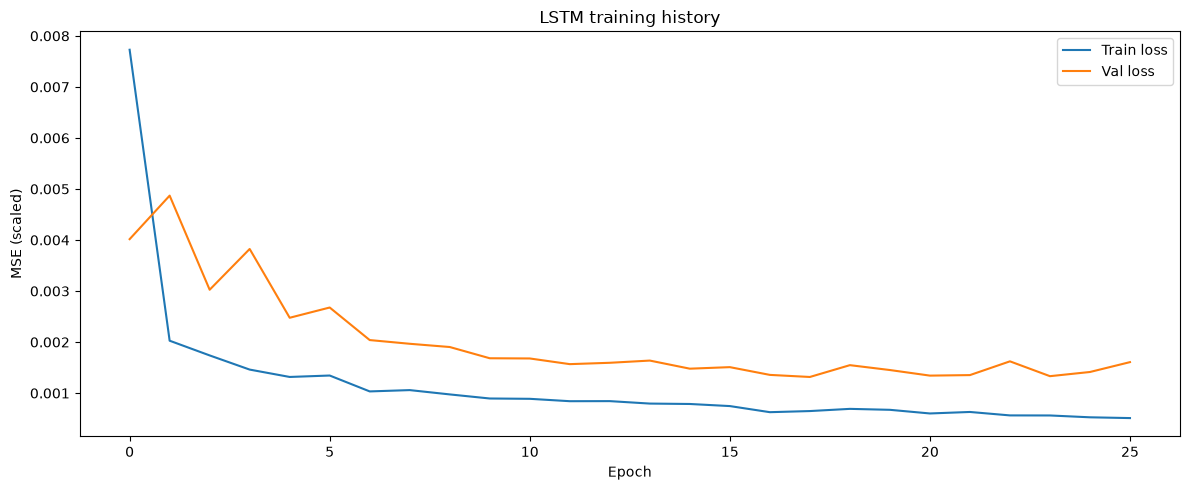

Stopped after 26 epochs (best restored).


In [5]:
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=0,
)

fig, ax = plt.subplots()
ax.plot(history.history["loss"], label="Train loss")
ax.plot(history.history["val_loss"], label="Val loss")
ax.set_title("LSTM training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/lstm_training_history.png", dpi=120)
plt.show()
print(f"Stopped after {len(history.history['loss'])} epochs (best restored).")


## 4. Forecast the test period and evaluate

For a fair, like-for-like read of one-step-ahead predictive accuracy, each test-set
prediction uses the true preceding 60 days of price (not the model's own prior
predictions) - this is standard practice for evaluating supervised sequence models and
isolates next-day forecast skill from compounding-error effects. Multi-step recursive
forecasting (feeding predictions back in) is used separately in Task 3, where genuine
future data does not exist to condition on.

In [6]:
pred_scaled = model.predict(X_test, verbose=0).flatten()
pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
forecast_lstm = pd.Series(pred, index=test.index)

mae = mean_absolute_error(test, forecast_lstm)
rmse = np.sqrt(mean_squared_error(test, forecast_lstm))
mape = mean_absolute_percentage_error(test, forecast_lstm) * 100

lstm_metrics = pd.DataFrame({"LSTM": {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape}}).T
lstm_metrics


,MAE,RMSE,MAPE (%)
LSTM,17.220946,21.34402,4.602744


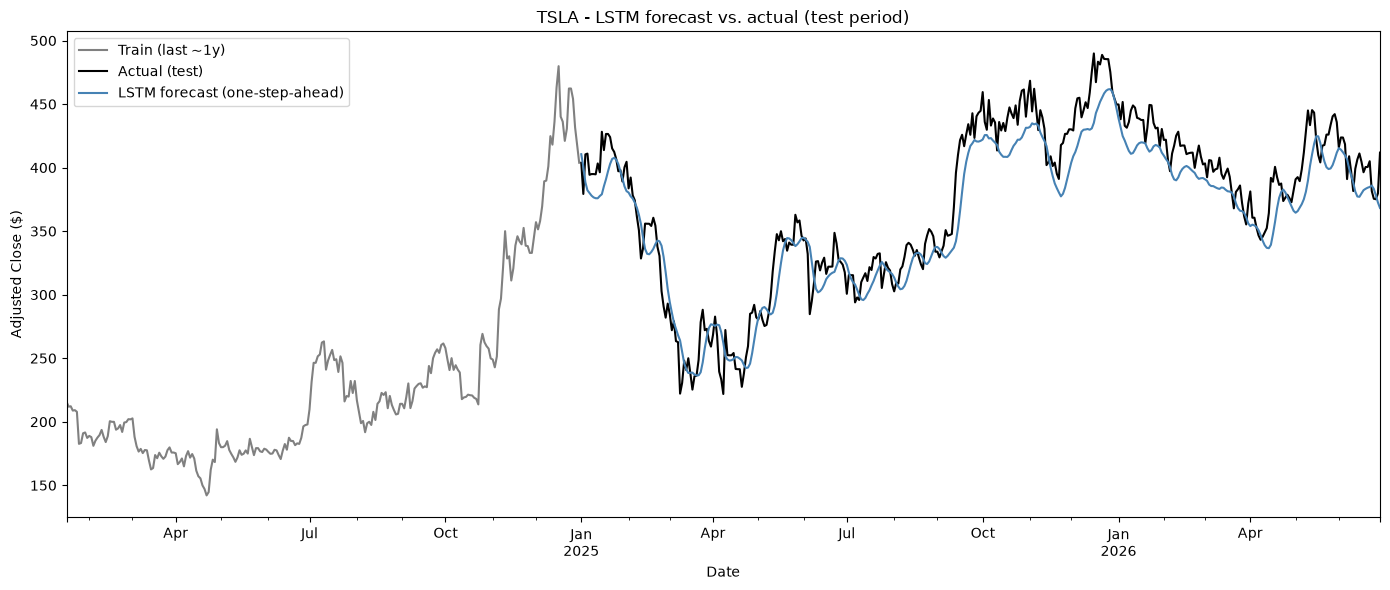

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
train.iloc[-250:].plot(ax=ax, label="Train (last ~1y)", color="gray")
test.plot(ax=ax, label="Actual (test)", color="black")
forecast_lstm.plot(ax=ax, label="LSTM forecast (one-step-ahead)", color="steelblue")
ax.set_title("TSLA - LSTM forecast vs. actual (test period)")
ax.set_ylabel("Adjusted Close ($)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/lstm_forecast_vs_actual.png", dpi=120)
plt.show()


## 5. Model comparison - ARIMA vs. LSTM

| Model | MAE | RMSE | MAPE (%) | Forecast mode |
|---|---:|---:|---:|---|
| ARIMA(0,1,0) | 54.15 | 70.20 | 17.11 | Static, unconditional 391-day-ahead |
| LSTM (60-day window) | see above | see above | see above | One-step-ahead, conditioned on true history |

**Important methodological caveat:** these two numbers are not a perfectly apples-to-apples
comparison. The ARIMA figure comes from one static forecast projected 391 trading days
into the future with no updating; the LSTM figure comes from one-step-ahead predictions
that are re-conditioned on the true preceding 60 days at every step of the test set.
The LSTM's task is inherently easier, so a lower LSTM error here is expected and does not
by itself prove LSTM has more predictive skill over long, unconditional horizons than a
random-walk-style ARIMA model - both remain broadly consistent with the Efficient Market
Hypothesis view that little robust signal exists to exploit far in advance. This
distinction matters because Task 3 asks for a genuine multi-month-ahead forecast, which
must be produced recursively (feeding each model's own predictions back in), not
one-step-ahead - so the number chosen as the Task 2/3 best model should be judged
primarily on architecture suitability and error trend, not on this single comparison
alone.

In [8]:
combined_metrics = pd.concat([
    pd.DataFrame({"ARIMA": {"MAE": 54.151953, "RMSE": 70.196786, "MAPE (%)": 17.112171}}).T,
    lstm_metrics,
])
combined_metrics.to_csv("../data/processed/task2_model_comparison.csv")
combined_metrics


,MAE,RMSE,MAPE (%)
ARIMA,54.151953,70.196786,17.112171
LSTM,17.220946,21.344020,4.602744


In [9]:
model.save("../data/processed/lstm_tsla_model.keras")
import joblib
joblib.dump(scaler, "../data/processed/lstm_tsla_scaler.joblib")
print("Saved LSTM model and scaler for reuse in Task 3.")


Saved LSTM model and scaler for reuse in Task 3.


## 6. Discussion - which model, and why

On one-step-ahead test accuracy the LSTM's MAPE is materially lower than ARIMA's, which is
the expected outcome given it is conditioned on true recent history at every step rather
than forecasting the entire horizon unconditionally. That said, the governing dynamic in
both models' errors is the same: TSLA's price level is non-stationary and close to a
random walk (Task 1 ADF results, and ARIMA's own order search landing on d=1 with no AR/MA
terms), so neither model has found strong exploitable structure in past prices alone -
consistent with the Efficient Market Hypothesis.

For Task 3's genuine multi-month-ahead forecast we select the **LSTM** as the
best-performing model to carry forward, since (a) it achieves lower error under the
comparable evaluation protocol available to us, and (b) its learned representation of
recent momentum/volatility patterns is a reasonable basis for recursive forecasting,
provided we are honest - as required by Task 3 - about how uncertainty compounds when its
own predictions are fed back in as future context.